In [12]:
import numpy as np 
import pandas as pd 
import scipy.stats as stats 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [13]:

from matplotlib import use
df = pd.read_csv('train.csv',usecols = ['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [14]:
df['Age'] = df['Age'].fillna(df['Age'].mean(),inplace=True)

/var/folders/95/rzjkbfr51kj6mtvk2yhx4vgm0000gp/T/ipykernel_74406/2393715946.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(df['Age'].mean(),inplace=True)


In [17]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

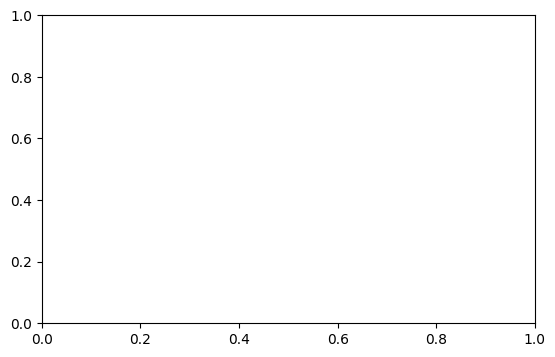

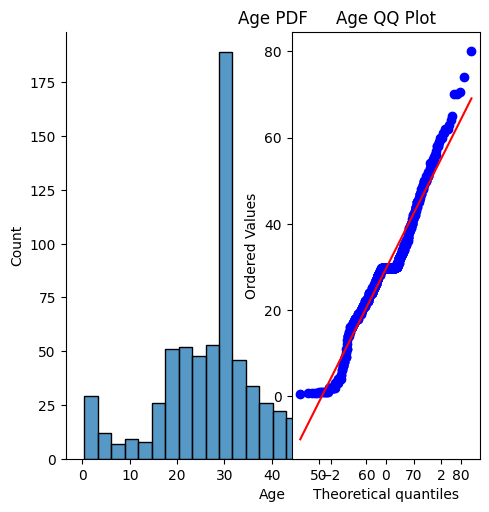

In [22]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.displot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ Plot')
plt.show()

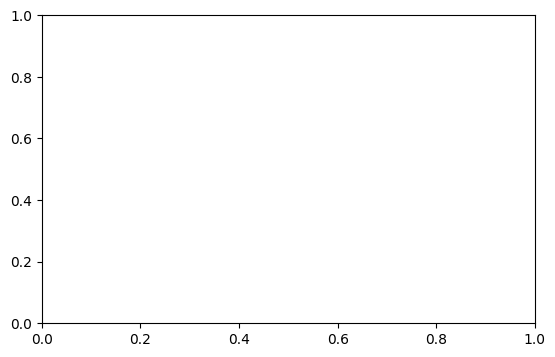

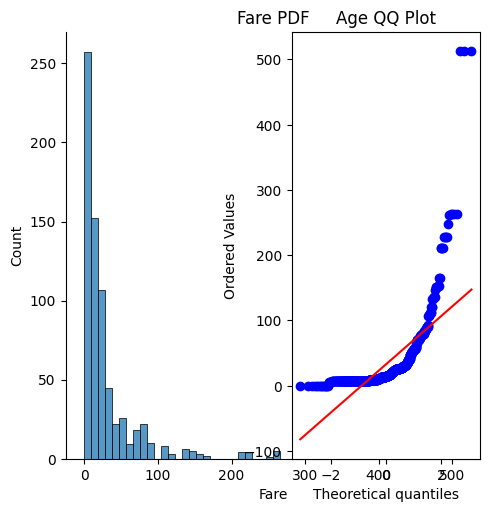

In [23]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.displot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Age QQ Plot')
plt.show()

In [24]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [26]:
clf.fit(X_train,y_train)
from sklearn.metrics import accuracy_score
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred2))



0.6480446927374302
0.6927374301675978


In [ ]:

trf = FunctionTransformer(func = np.log1p)

In [29]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.fit_transform(X_test)

In [30]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
from sklearn.metrics import accuracy_score
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred2 = clf2.predict(X_test_transformed)

print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred2))

0.6815642458100558
0.6759776536312849


In [32]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print(np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print(np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

0.678027465667915
0.6588389513108613


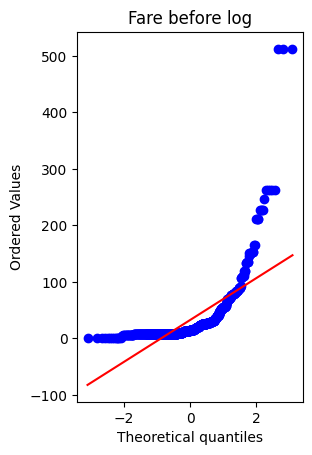

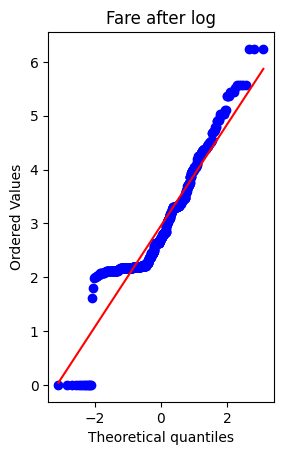

In [34]:
plt.subplot(121)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare before log')
plt.show()

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist='norm', plot=plt)
plt.title('Fare after log')
plt.show()

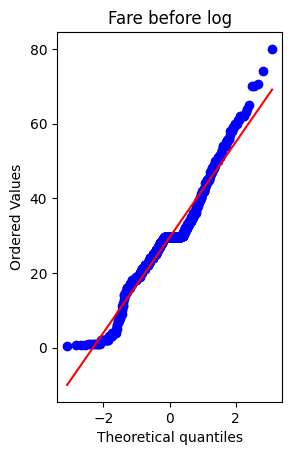

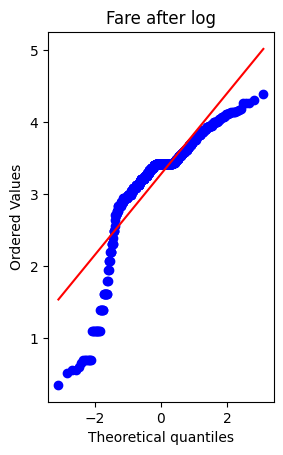

In [35]:
plt.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Fare before log')
plt.show()

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist='norm', plot=plt)
plt.title('Fare after log')
plt.show()

In [37]:
trf2 = ColumnTransformer([

    ('log',FunctionTransformer(np.log1p),['Fare'])
],remainder ='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.fit_transform(X_test)

In [38]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
from sklearn.metrics import accuracy_score
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred2))

0.6703910614525139
0.659217877094972


In [39]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print(np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print(np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

0.6712609238451936
0.6633333333333333


In [40]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    

Accuracy 0.6589013732833957


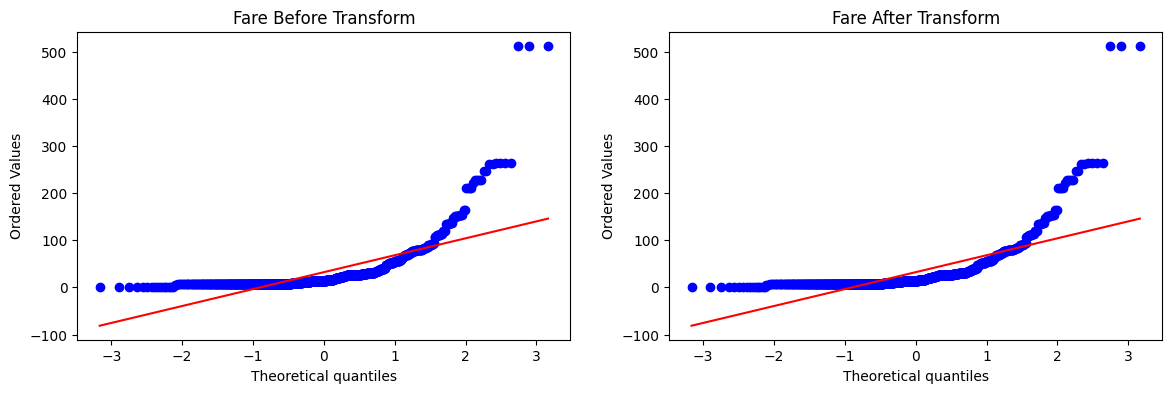

In [41]:
apply_transform(lambda x: x)

Accuracy 0.6431335830212235


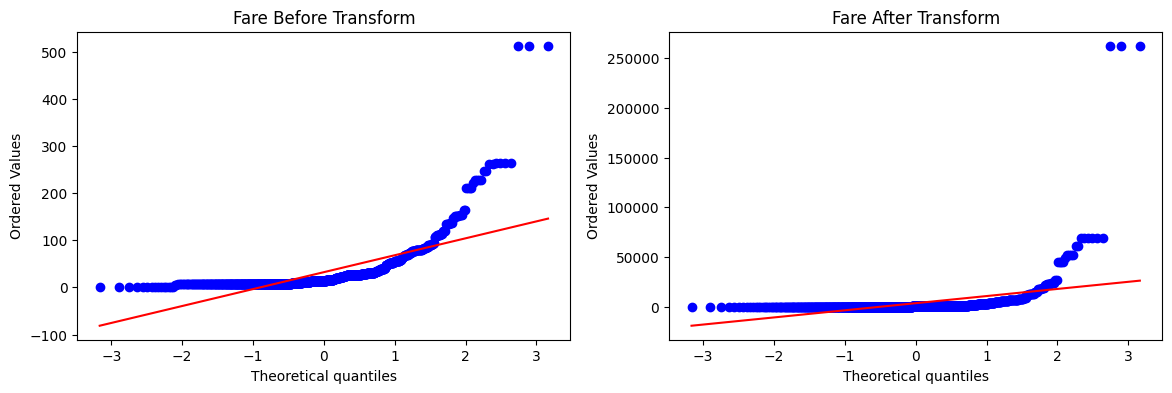

In [42]:
apply_transform(lambda x: x**2)

Accuracy 0.6611485642946316


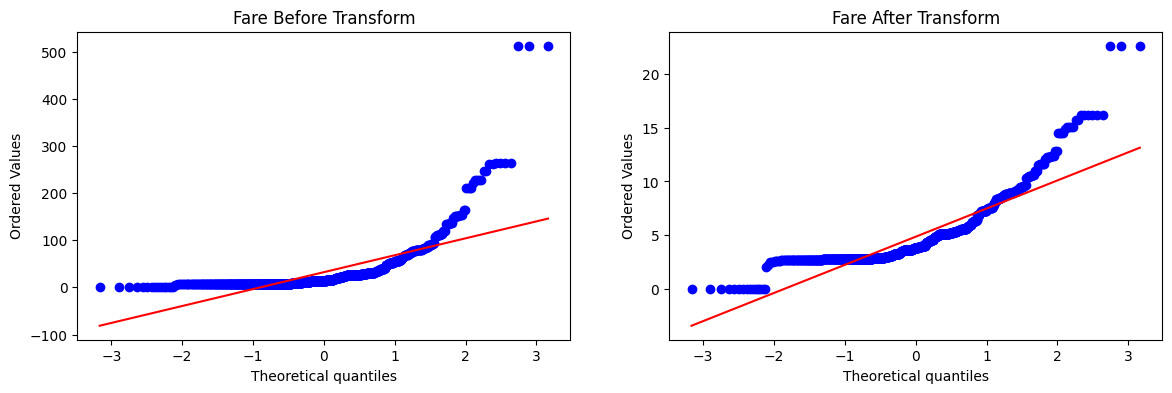

In [43]:
apply_transform(lambda x: x**0.5)

Accuracy 0.61729088639201


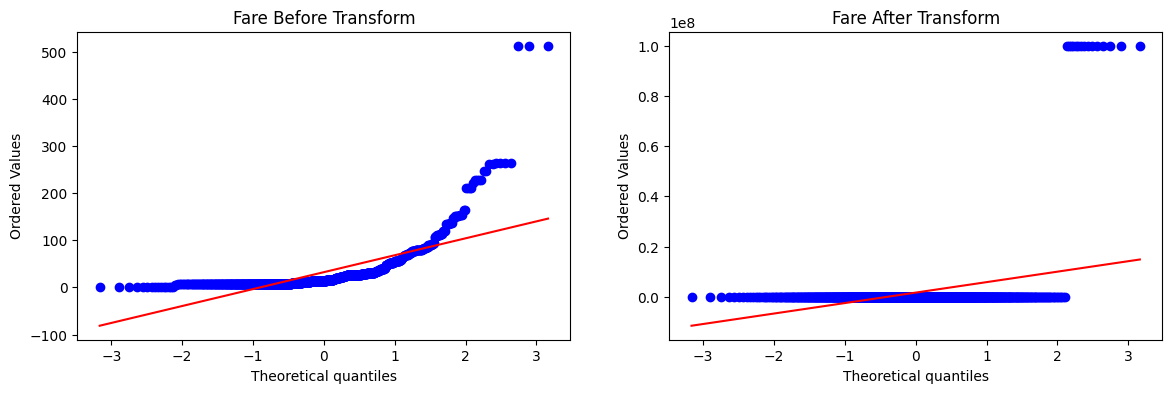

In [47]:
apply_transform(lambda x: 1/(x+0.00000001))